### Explorty Data Analysis
- Checking Inconsistent values in categorical columns
- Checking Invalid values in Numerical columns
- Checking Outlies
- Checking Null values
- Checking columns dtypes
- Checking columns name
- Skewness of the data
- Distribution of the (Numerical,Categorical)
- imbalanced
- Correlation

In [3]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('../E-commerce_data/ecommerce_dirty_100k_20cols.csv')

In [4]:
df.shape

(100000, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              100000 non-null  object 
 1   customer_id           100000 non-null  object 
 2   order_date            99403 non-null   object 
 3   customer_age          98210 non-null   float64
 4   city                  98735 non-null   object 
 5   category              98474 non-null   object 
 6   product_name          99600 non-null   object 
 7   quantity              99307 non-null   float64
 8   unit_price            98906 non-null   object 
 9   discount_pct          98408 non-null   object 
 10  payment_method        98674 non-null   object 
 11  order_status          99205 non-null   object 
 12  rating                97205 non-null   float64
 13  shipping_days         96540 non-null   float64
 14  delivery_distance_km  97913 non-null   object 
 15  d

In [6]:
df.head()

,order_id,customer_id,order_date,customer_age,city,category,product_name,quantity,unit_price,discount_pct,payment_method,order_status,rating,shipping_days,delivery_distance_km,device,marketing_channel,customer_spend_90d,coupon_code,total_amount
0,ORD1048298,CUST55152,2025.08.45,33.0,Lucknow,Grocery,Bluetooth Speaker,1.0,1270.11,15.27,COD,Delivered,3.6,4.0,4.74,Desktop,Social,10552.73,NEWUSER,1076.16
1,ORD1081047,CUST35058,2025-08-14,28.0,Chennai,Home & Kitchen,Running Shoes,1.0,1030.57,1.5,UPI,Delivered,5.0,3.0,16.72,Mobile,Social,894.36,FESTIVE,1015.11
2,ORD1092754,CUST67495,2025-11-08,31.0,Pune,Beauty,Face Serum,1.0,284.83,15.65,UPI,Delivered,5.0,6.0,4.4,Mobile,Organic,9866.55,NEWUSER,240.25
3,ORD1046007,CUST74685,2024-12-01,38.0,Indore,Home & Kitchen,Novel,3.0,NaN,14.26,Credit Card,Shipped,5.0,6.0,12.49,Mobile,Social,1240.55,APP15,2999.96
4,ORD1076981,CUST11836,2025-07-15,18.0,Chennai,Electronics,Laptop Stand,2.0,936.59,13.63,Wallet,Shipped,4.2,3.0,9.91,Mobile,Organic,17111.92,SAVE20,1617.87


### Correct columns formating

In [7]:
df.rename(columns={
    "order_id":"OrderId",
    "customer_id":"CustomerId",
    "order_date":"OrderDate",
    "customer_age":"Age",
    "city":"City",
    "category":"Category",
    "product_name":"ProductName",
    "quantity":"Quantity",
    "unit_price":"UnitPrice",
    "discount_pct":"DiscountPct",
    "payment_method":"PaymentMethod",
    "order_status":"OrderStatus",
    "rating":"Rating",
    "shipping_days":"ShippingDays",
    "delivery_distance_km":"DeliveryDistanceKM",
    "device":"Device",
    "marketing_channel":"MarketingChannel",
    "customer_spend_90d":"Spend90d",
    "coupon_code":"CouponCode",
    "total_amount":"TotalAmount"
},inplace=True)

In [8]:
df.isnull().mean() * 100

OrderId               0.000
CustomerId            0.000
OrderDate             0.597
Age                   1.790
City                  1.265
Category              1.526
ProductName           0.400
Quantity              0.693
UnitPrice             1.094
DiscountPct           1.592
PaymentMethod         1.326
OrderStatus           0.795
Rating                2.795
ShippingDays          3.460
DeliveryDistanceKM    2.087
Device                0.910
MarketingChannel      1.624
Spend90d              2.589
CouponCode            4.482
TotalAmount           0.895
dtype: float64

### CHECKING DTYPES

In [9]:
df.dropna(subset=['Age'],inplace=True)

In [10]:
df['UnitPrice'] = df['UnitPrice'].str.replace("₹"," ")

In [11]:
df['DiscountPct'] = df['DiscountPct'].str.replace("%"," ")
df['DiscountPct'] = df['DiscountPct'].str.strip()
df['DiscountPct'] = pd.to_numeric(df['DiscountPct'])

In [12]:
df['ShippingDays'] = pd.to_numeric(df['ShippingDays'])

In [13]:
df['DeliveryDistanceKM'] = df['DeliveryDistanceKM'].str.replace("km"," ")
df['DeliveryDistanceKM'] = df['DeliveryDistanceKM'].str.strip()
df['DeliveryDistanceKM'] = pd.to_numeric(df['DeliveryDistanceKM'])

In [14]:
df.head(2)

,OrderId,CustomerId,OrderDate,Age,City,Category,ProductName,Quantity,UnitPrice,DiscountPct,PaymentMethod,OrderStatus,Rating,ShippingDays,DeliveryDistanceKM,Device,MarketingChannel,Spend90d,CouponCode,TotalAmount
0,ORD1048298,CUST55152,2025.08.45,33.0,Lucknow,Grocery,Bluetooth Speaker,1.0,1270.11,15.27,COD,Delivered,3.6,4.0,4.74,Desktop,Social,10552.73,NEWUSER,1076.16
1,ORD1081047,CUST35058,2025-08-14,28.0,Chennai,Home & Kitchen,Running Shoes,1.0,1030.57,1.50,UPI,Delivered,5.0,3.0,16.72,Mobile,Social,894.36,FESTIVE,1015.11


In [15]:
df['Spend90d']  = df['Spend90d'].str.replace("₹","")
df['Spend90d']  = df['Spend90d'].str.strip()
df['Spend90d']  = pd.to_numeric(df['Spend90d'])

In [16]:
df['TotalAmount']  = df['TotalAmount'].str.replace("₹","")
df['TotalAmount']  = df['TotalAmount'].str.strip()
df['TotalAmount']  = pd.to_numeric(df['TotalAmount'])

### Observation:
- The dataset contain corret dtypes

### CHECKING INCONSISTENT VLAUES IN CATEGORICAL COLUMNS

In [17]:
categorical_columns = df.select_dtypes(include=['object'])

for col in categorical_columns:
    print("Columns",col)
    print(df[col].unique())
    print()

Columns OrderId
['ORD1048298' 'ORD1081047' 'ORD1092754' ... 'ORD1057399' 'ORD1097106'
 'ORD1000478']

Columns CustomerId
['CUST55152' 'CUST35058' 'CUST67495' ... 'CUST29496' 'CUST79298'
 'CUST63164']

Columns OrderDate
['2025.08.45' '2025-08-14' '2025-11-08' '2024-12-01' '2025-07-15'
 '01/13/2025' '2024-11-10' '2025-11-18' '2025-06-28' '2024-06-01'
 '2024-09-08' '2024-04-20' '2025-07-25' '2024-09-25' '2025-05-13'
 '2024-11-07' '2024-02-28' '2024-02-04' '2025-01-10' '2024-01-16'
 '2025-07-10' '2025-06-22' '2024-11-19' '2024-08-30' '2025-03-26'
 '2024-05-31' '2024-04-14' '2024-02-27' '2025-03-20' '2025-01-19'
 '2024-05-05' '2024-03-19' '2024-06-27' '2025-12-22' '2025-05-15'
 '2025-05-24' '2025-10-11' '2025-08-03' '2024-04-18' '2024-05-18'
 '2024-12-03' '2024-03-12' '2024-03-10' '2025-06-03' '2024-05-19'
 '2024-07-31' '2024-07-09' '2024-07-07' '2025-07-08' '2025-01-04'
 '2025-12-19' '2024-08-04' '2024-02-24' '2025-09-16' '2024-10-22'
 '2024-09-16' '2024-10-01' '2024-02-12' '2024-07-25' '2

### Obervation:
- The dataset contain inconsistent values for every categorical columns

### CHECKING INVLID VALUES IN NUMERICAL COLUMNS

In [18]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_columns:
    print("Columns",col)
    print(df[col].min())
    print(df[col].max())
    print()

Columns Age
-5.0
150.0

Columns Quantity
-3.0
1000.0

Columns DiscountPct
-10.0
999.0

Columns Rating
-1.0
10.0

Columns ShippingDays
-4.0
999.0

Columns DeliveryDistanceKM
-10.0
9999.0

Columns Spend90d
25.03
1998985.9

Columns TotalAmount
4.23
4983191.71



### Observation:
- The Dataset contain Invalid values

### OUTLIERS DETECTION

In [19]:
numerical_columns = df.select_dtypes(include=['int','float64']).columns

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print("Columns:",col)
    print("Outliers:", len(outliers))
    print()

Columns: Age
Outliers: 917

Columns: Quantity
Outliers: 10302

Columns: DiscountPct
Outliers: 1680

Columns: Rating
Outliers: 710

Columns: ShippingDays
Outliers: 4285

Columns: DeliveryDistanceKM
Outliers: 6733

Columns: Spend90d
Outliers: 8584

Columns: TotalAmount
Outliers: 9010



### Obersvation:
- The Dataset contain outliers

### Distribution of Numerical Columns

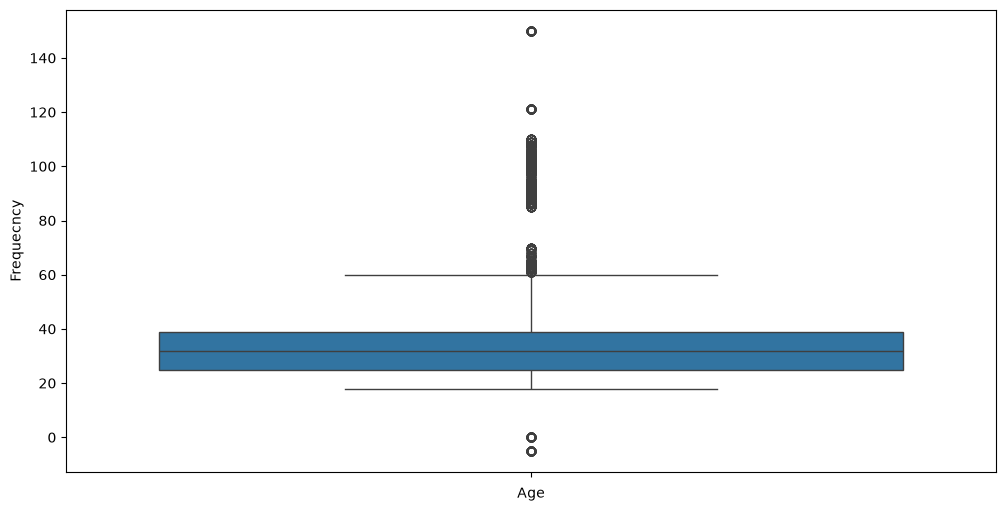

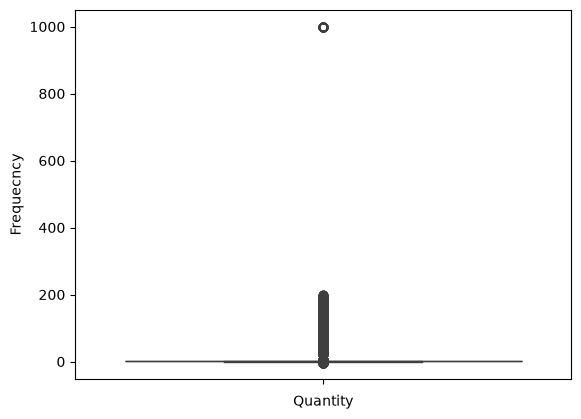

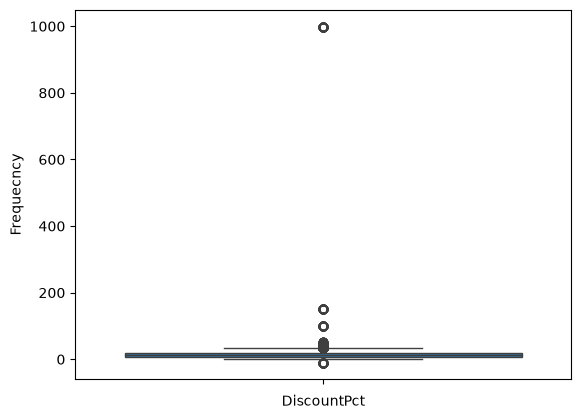

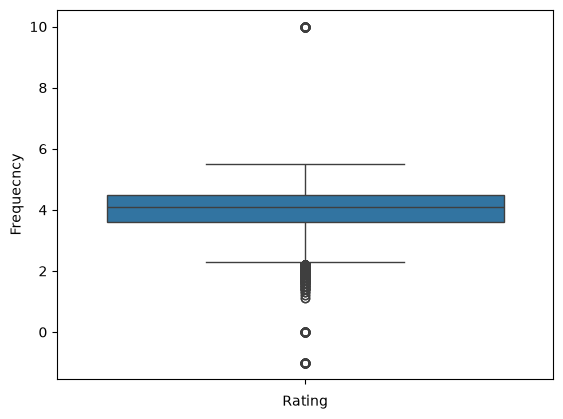

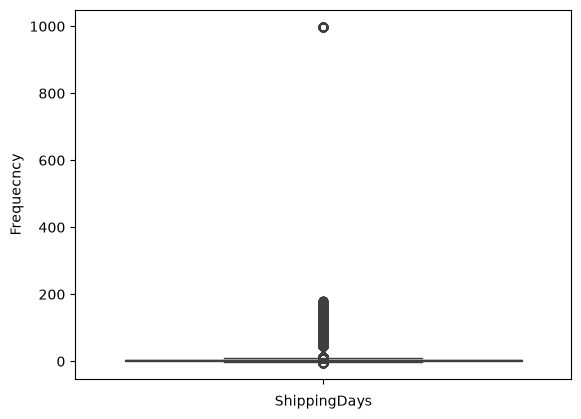

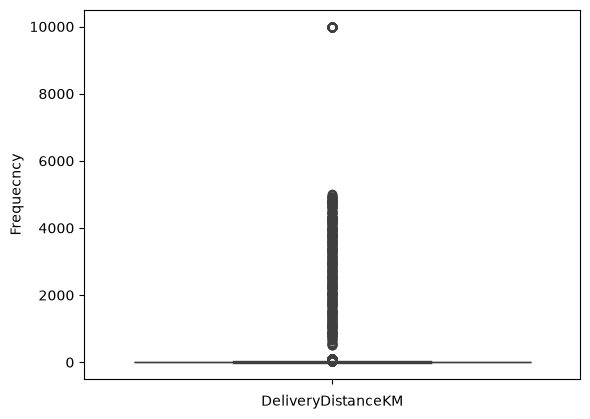

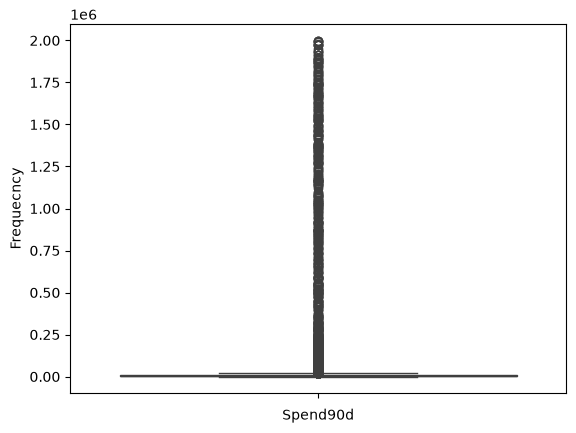

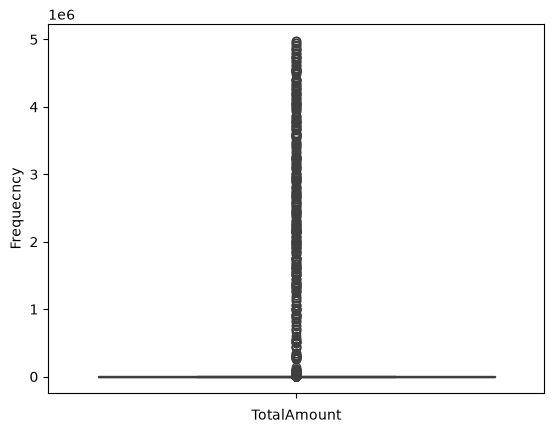

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
for col in numerical_columns:
    sns.boxplot(df[col])
    plt.xlabel(f"{col}")
    plt.ylabel("Frequecncy")
    plt.show()

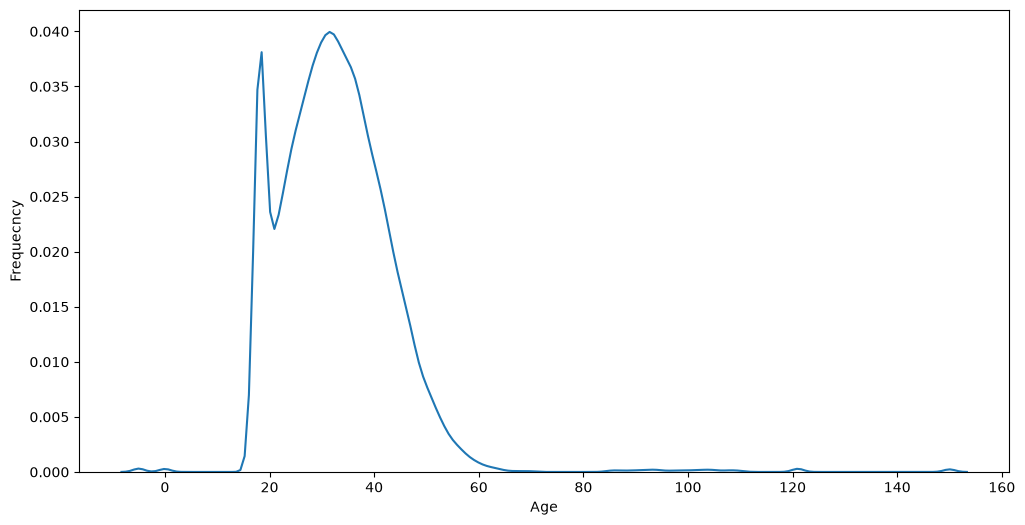

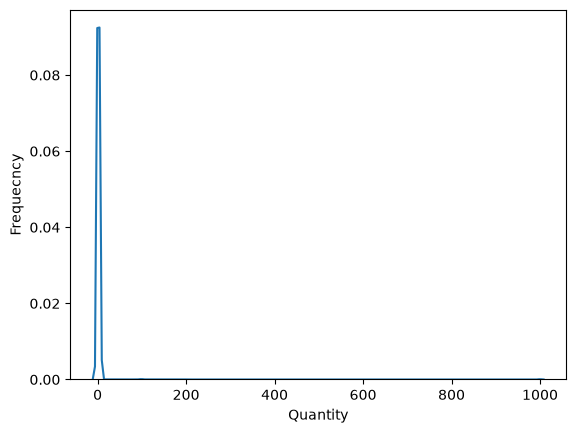

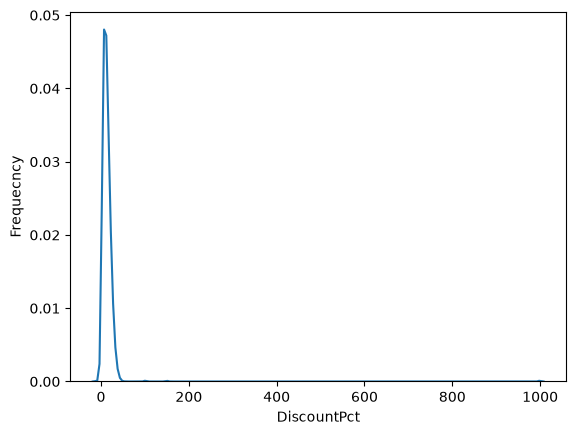

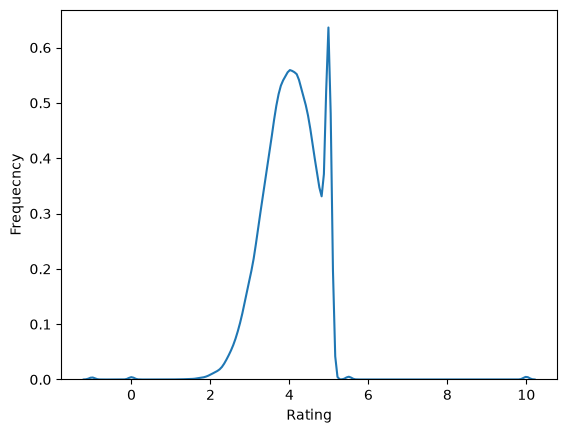

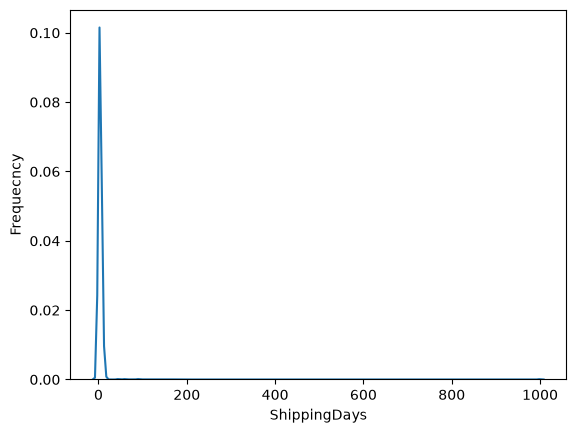

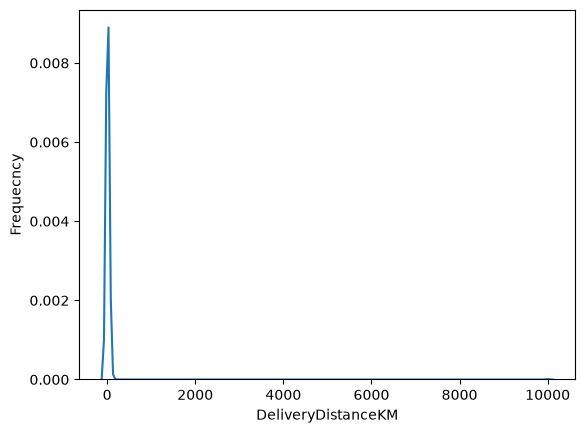

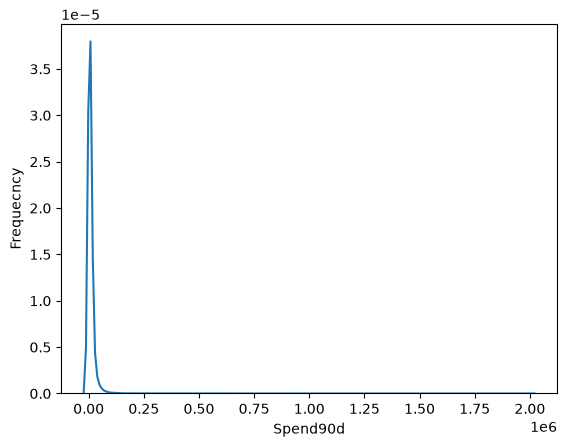

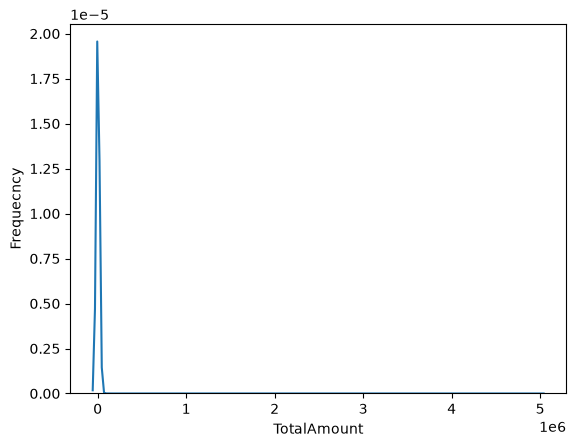

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
for col in numerical_columns:
    sns.kdeplot(df[col])
    plt.xlabel(f"{col}")
    plt.ylabel("Frequecncy")
    plt.show()

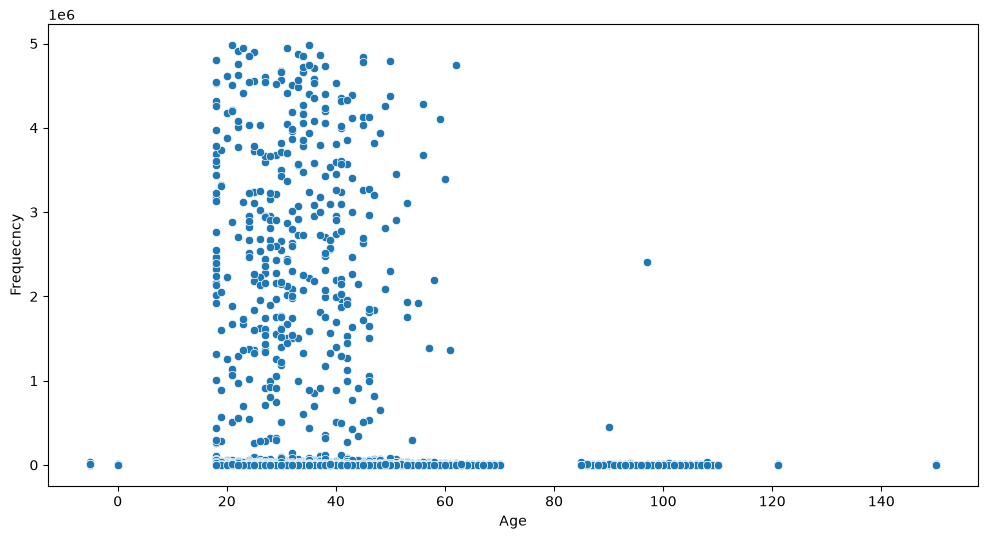

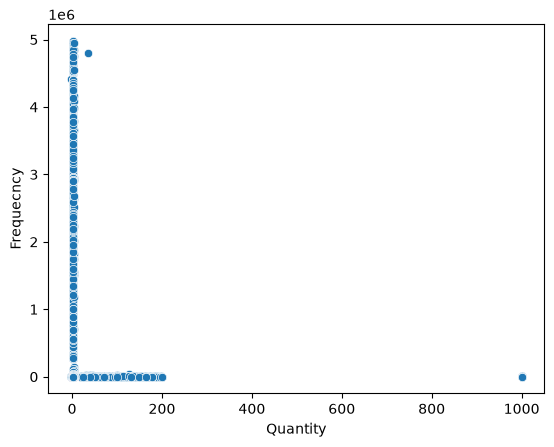

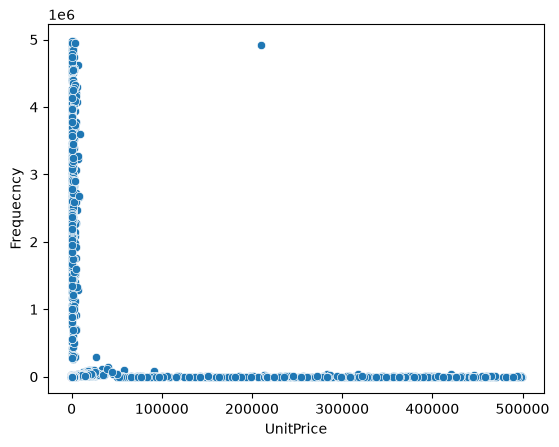

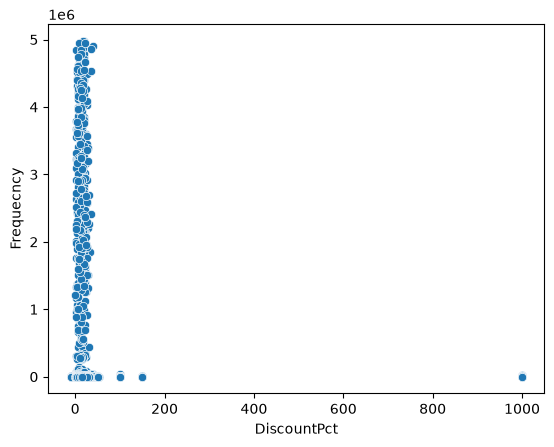

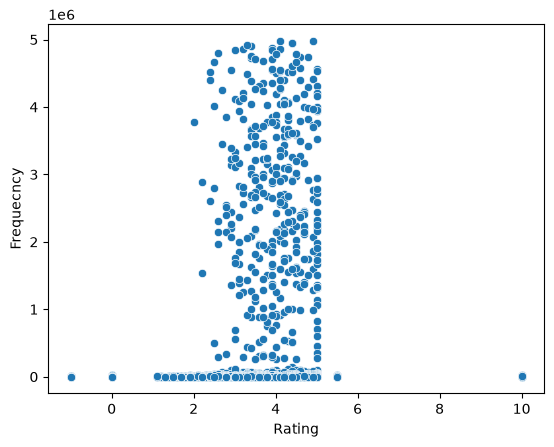

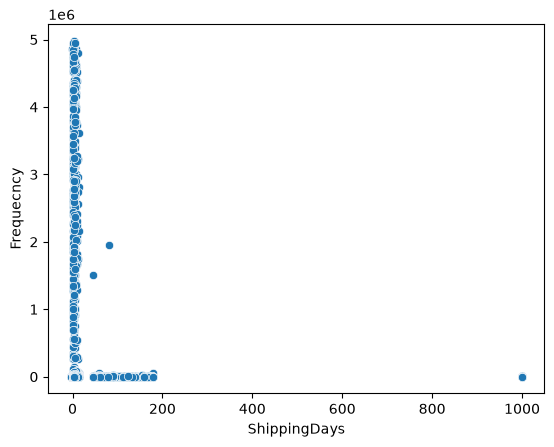

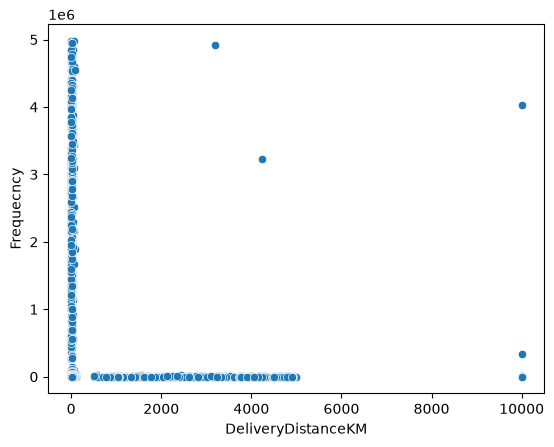

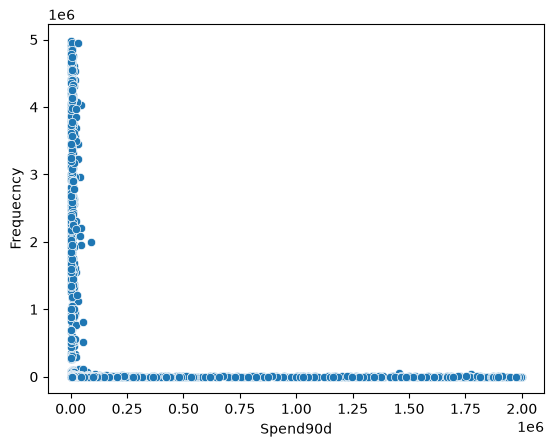

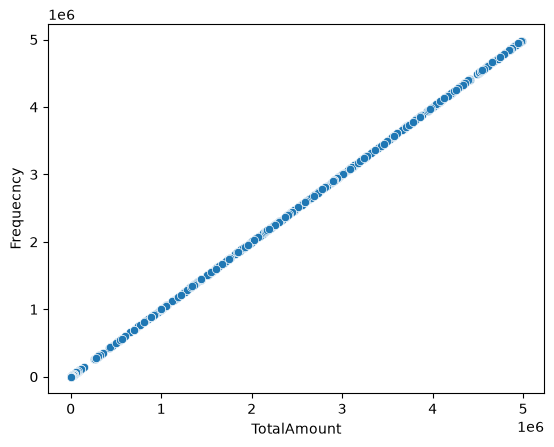

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
for col in numerical_columns:
    sns.scatterplot(data=df, x  = df[col], y = "TotalAmount")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequecncy")
    plt.show()

### Distribution of Categorical column

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# categorical_columns = df.select_dtypes(include=['object']).columns
# # plt.figure(figsize=(12,6))
# for col in categorical_columns:
#     sns.barplot(data=df, x  = df[col], y = "TotalAmount")
#     plt.xlabel(f"{col}")
#     plt.ylabel("Frequecncy")
#     plt.show()

<Axes: >

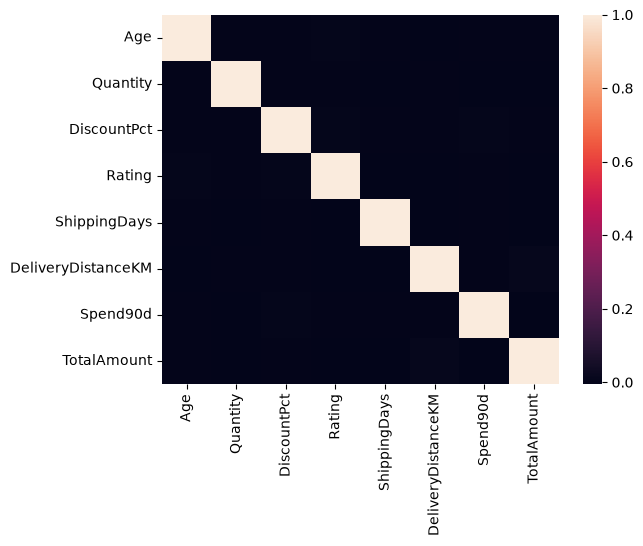

In [22]:
sns.heatmap(df.corr(numeric_only=True))

In [24]:
df.to_csv("EDA_completed.csv")